In [1]:
import torch

from scripts.material_aware_training import _material_aware_training, build_flame_server
from scripts.config import PathConfig, MaterialAwareTrainingConfig
from flare.dataset import DatasetLoader

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [2]:
working_dir = "/home/jsickert/adl4cv"
run_name = "001"
input_dir = "DATA/001"
train_dir = ["MVI_1814", "MVI_1810"]
output_dir = "out"
flame_path = "/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl"
diffusion_dir = None
ghostbone = True
batch_size = 2
eval_dir = ["MVI_1812"]

path_config = PathConfig(
    _working_dir=working_dir,
    run_name=run_name,
    input_dir=input_dir,
    output_dir=output_dir,
    flame_path=flame_path,
    diffusion_dir=diffusion_dir,
    train_dir=train_dir,
    eval_dir=eval_dir,
)

In [3]:
dataset_train = DatasetLoader(path_config, train_dir=train_dir, sample_ratio=1, pre_load=True)

dataloader_train = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=batch_size,
    collate_fn=dataset_train.collate,
    shuffle=True,
    drop_last=True,
)

loaded 2903 views


In [4]:
FLAMEServer = build_flame_server(dataset_train, flame_path, ghostbone)

creating the FLAME Decoder


In [5]:
training_config = MaterialAwareTrainingConfig.default_stage_1_config(batch_size=batch_size, ghostbone=ghostbone)

_material_aware_training(
    path_config=path_config,
    training_config=training_config,
    dataset_train=dataset_train,
    dataloader_train=dataloader_train,
    FLAMEServer=FLAMEServer,
)

Rasterizing: ['mask', 'position', 'normal', 'canonical_position']
Training Deformer
STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128], 'light_mlp_dims': [64, 64]}
{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.01, 'white_light_regularization': 0.01, 'fresnel_coeff': 0.01, 'flame_regularization': 1.0, 'diffusion_normal': 0.0, 'diffusion_albedo': 0.0, 'diffusion_roughness': 0.0, 'diffusion_irradiance': 0.0}


Epoch 0, Iter 1:   0%|          | 0/2 [00:00<?, ?it/s]Using /home/jsickert/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/jsickert/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...
Epoch 0, Iter 101:   0%|          | 0/2 [00:32<?, ?it/s, loss=0.341]

Decaying flame regularization


Epoch 0, Iter 500:   0%|          | 0/2 [02:00<?, ?it/s, loss=0.263]

Upsampling at iteration: 500
Vertices: (17620, 3)
Faces: (35200, 3)
laplacian weight 240.0
normal consistency weight 0.4
lr vertices 0.00075


Epoch 1, Iter 2902: 100%|██████████| 2/2 [11:26<00:00, 343.08s/it, loss=0.0724]

TIME TAKEN (mins): 11


In [6]:
from scripts.flare_inference import build_flare_pipeline, run_inference, visualize_image_batch, visualize_image_buffers

In [7]:
dataset_val = DatasetLoader(path_config, train_dir=path_config.eval_dir, sample_ratio=1, pre_load=False)
dataloader_validate = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate, shuffle=True)

In [18]:
mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt = build_flare_pipeline(
    dataset_val=dataset_val,
    flame_path=flame_path,
    mesh_path=path_config.working_dir / output_dir / run_name / "stage_1/meshes/mesh_latest.obj",
    deformer_path=path_config.working_dir / output_dir / run_name / "stage_1/network_weights/deformer_latest.pt",
    shader_path=path_config.working_dir / output_dir / run_name / "stage_1/network_weights/shader_latest.pt",
    train_dir=train_dir,
)

# mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt = build_flare_pipeline(
#     dataset_val=dataset_val,
#     flame_path=flame_path,
#     mesh_path=path_config.working_dir / "out_default" / "001" / "stage_1/meshes/mesh_latest.obj",
#     deformer_path=path_config.working_dir / "out_default" / "001" / "stage_1/network_weights/deformer_latest.pt",
#     shader_path=path_config.working_dir / "out_default" / "001" / "stage_1/network_weights/shader_latest.pt",
#     train_dir=train_dir,
# )

# mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt = build_flare_pipeline(
#     dataset_val=dataset_val,
#     flame_path="/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl",
#     mesh_path="/home/jsickert/adl4cv/MODELS/001/stage_1/meshes/mesh_latest.obj",
#     deformer_path="/home/jsickert/adl4cv/MODELS/001/stage_1/network_weights/deformer_latest.pt",
#     shader_path="/home/jsickert/adl4cv/MODELS/001/stage_1/network_weights/shader_latest.pt",
#     train_dir=train_dir,
# )

creating the FLAME Decoder
STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128], 'light_mlp_dims': [64, 64]}


In [9]:
for it, views in enumerate(dataloader_validate):
    break

print(views["frame_name"])

['916', '373', '735', '1413']


In [19]:
rgb_pred, gbuffers, cbuffers = run_inference(views, mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt)

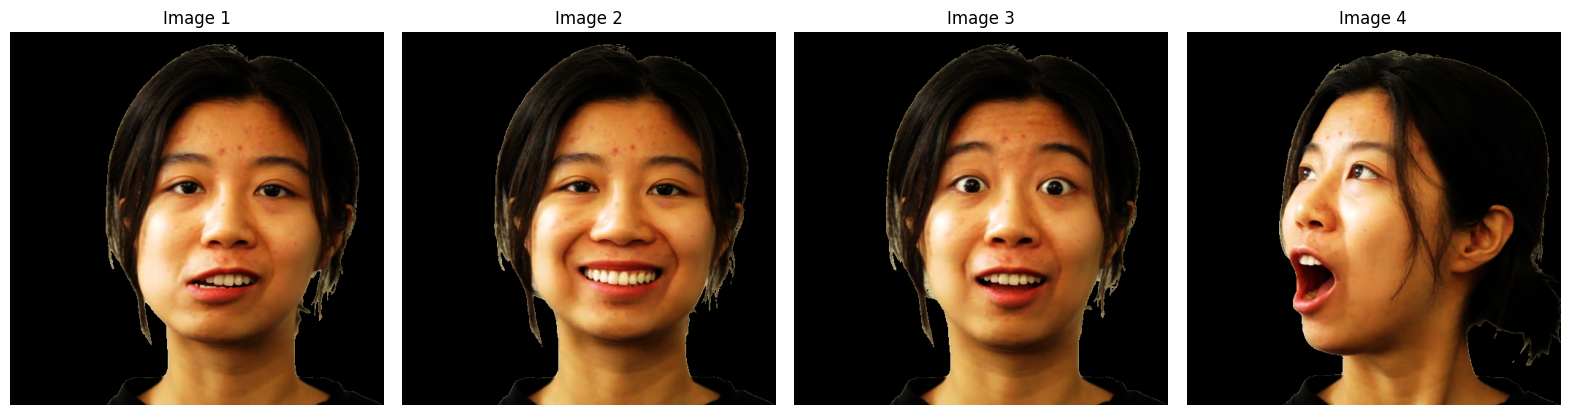

In [11]:
visualize_image_batch(views["img"])

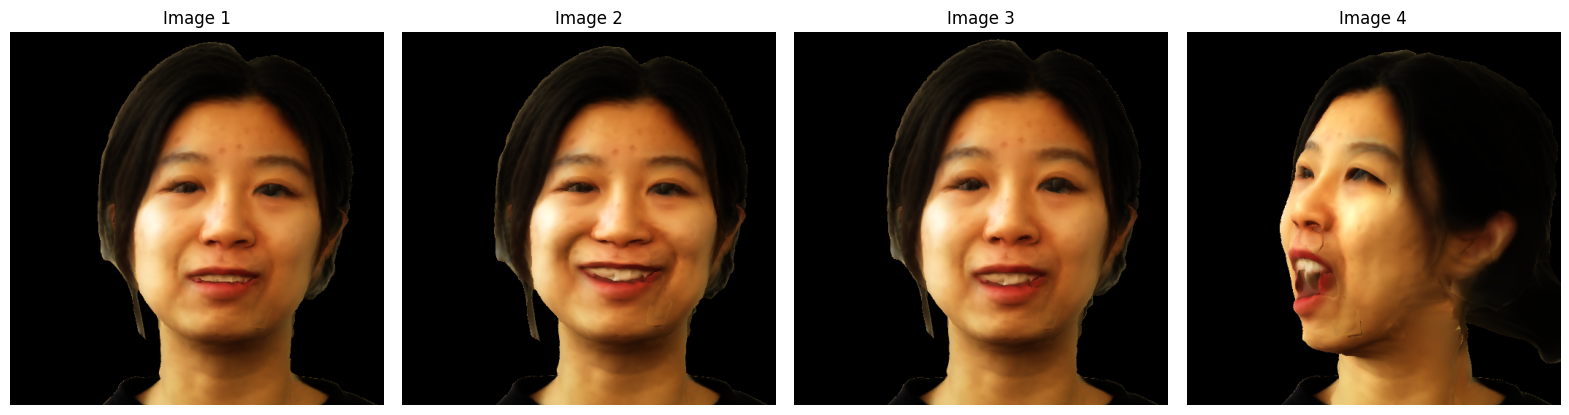

In [20]:
visualize_image_batch(rgb_pred)

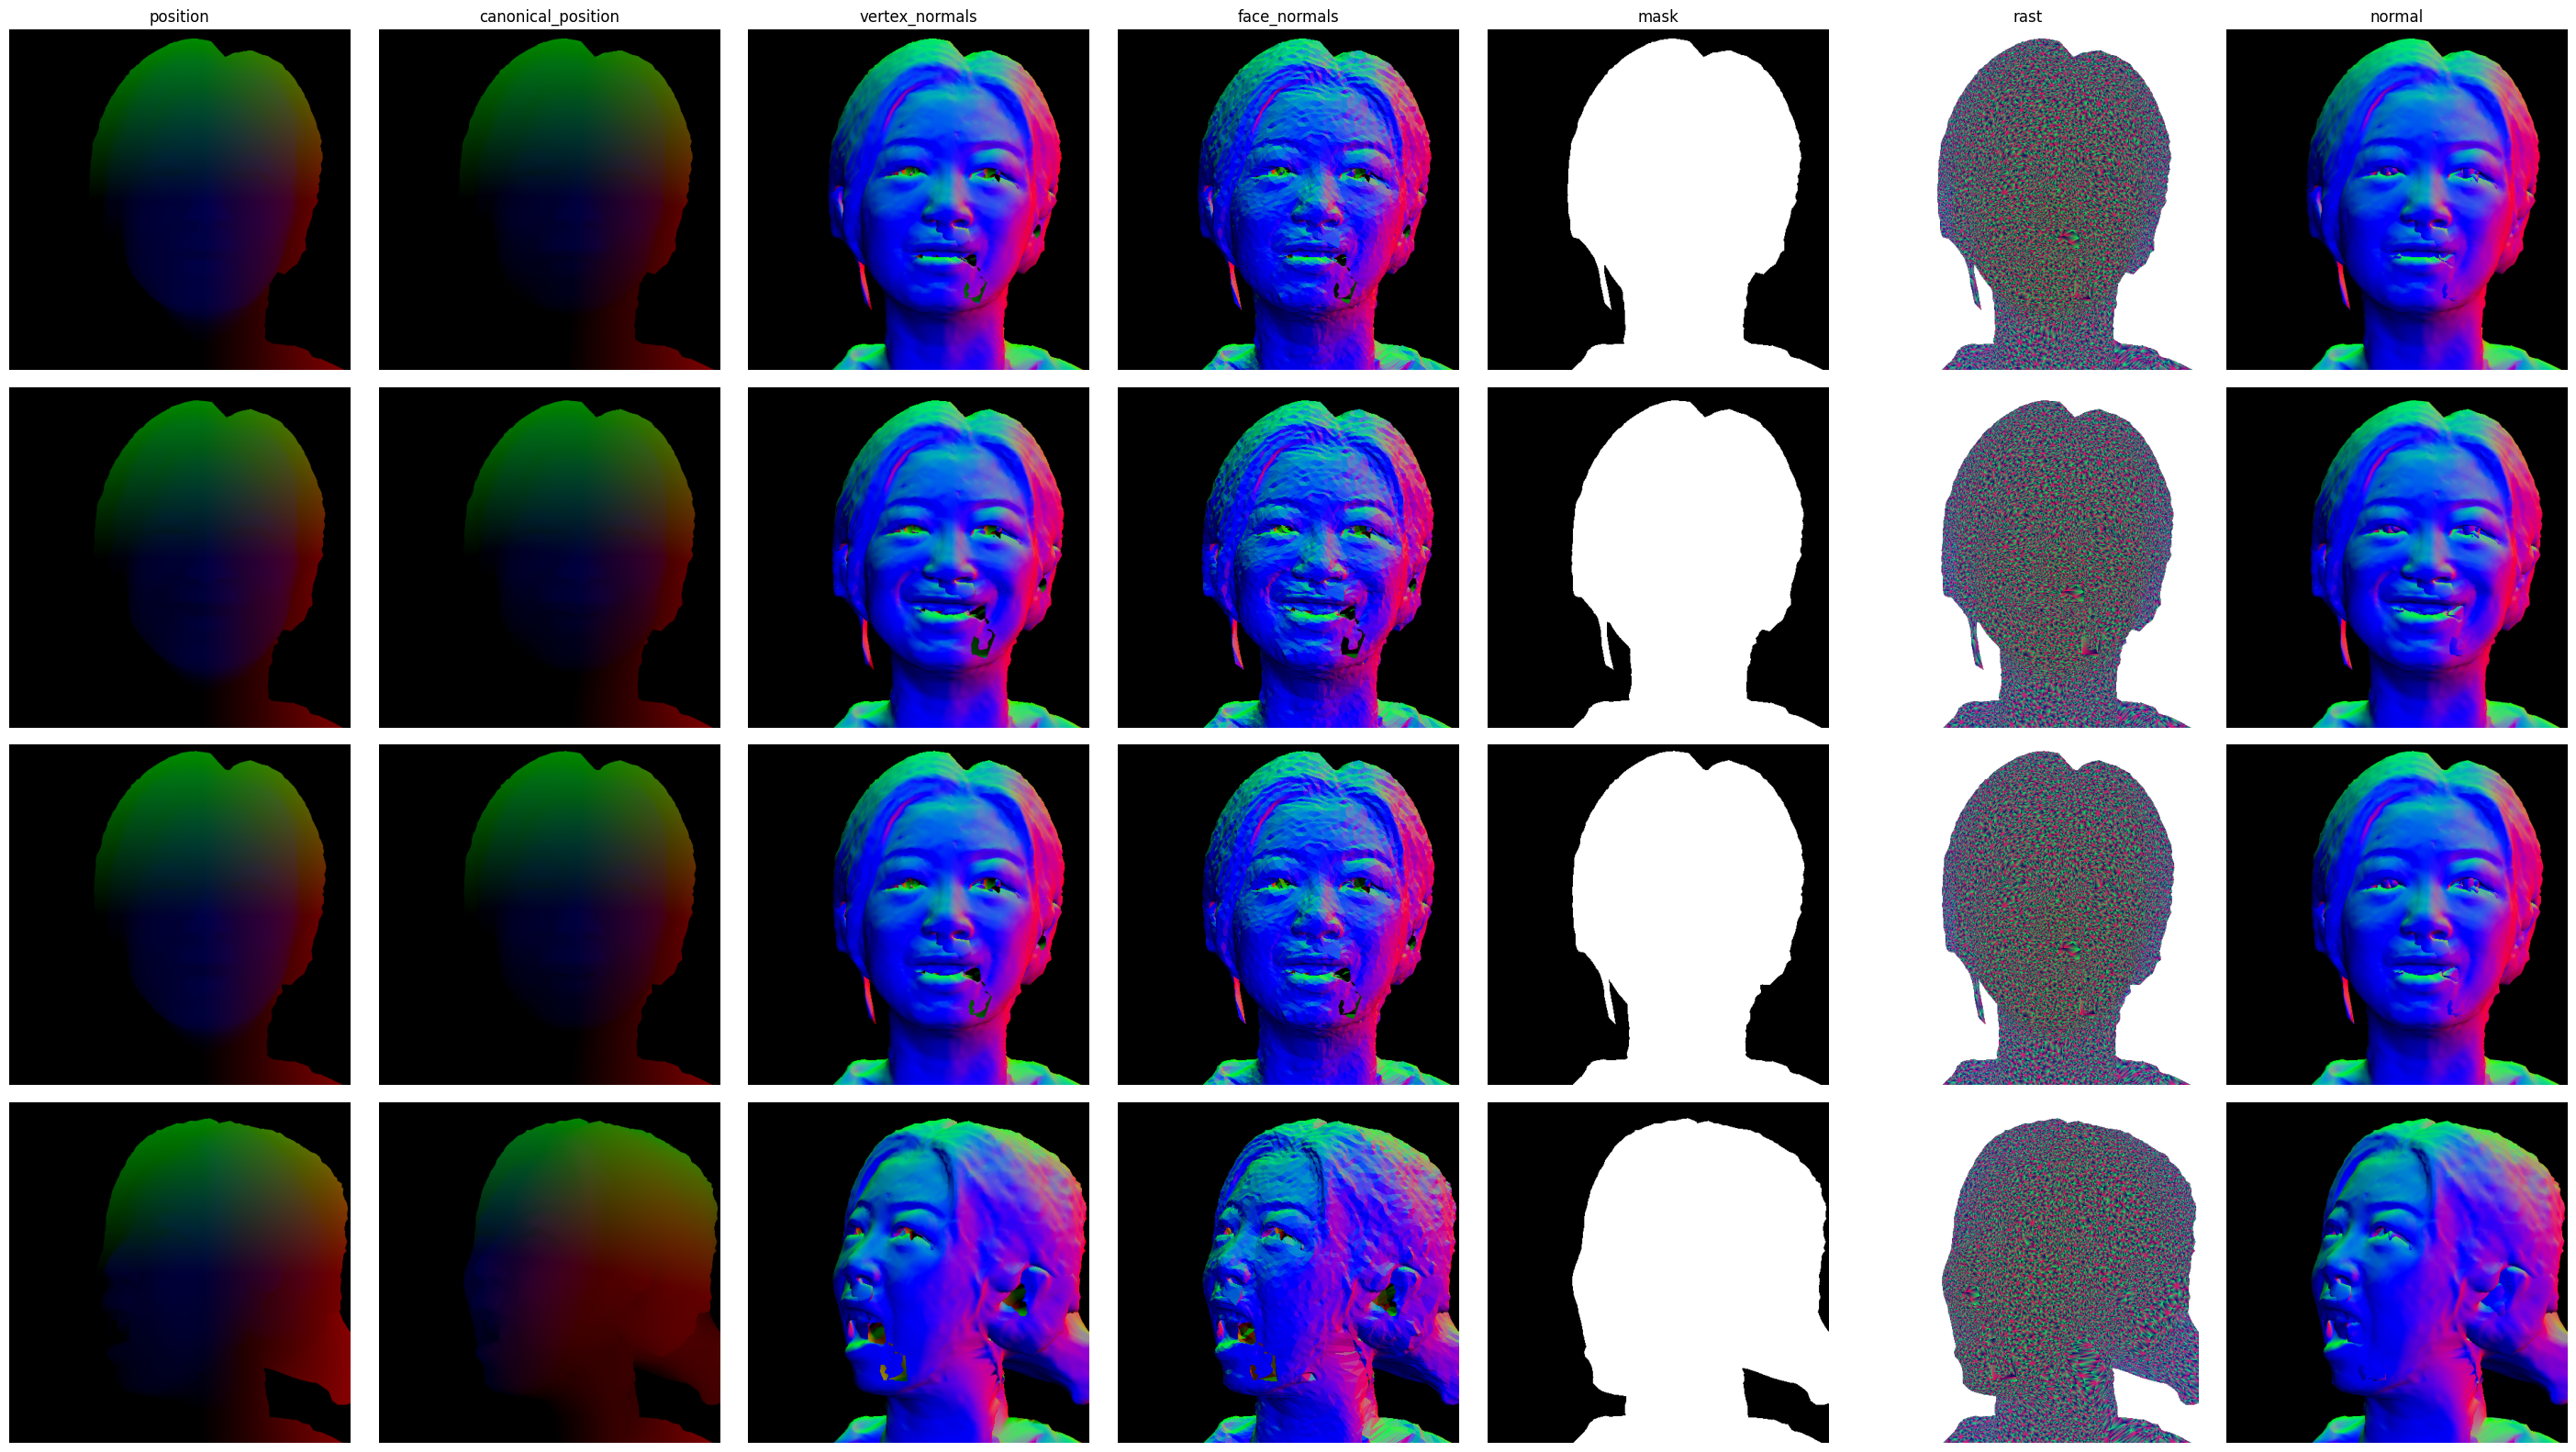

In [21]:
_gbuffers = {}
_gbuffers["position"] = gbuffers["position"]
_gbuffers["canonical_position"] = gbuffers["canonical_position"]
_gbuffers["vertex_normals"] = gbuffers["vertex_normals"]
_gbuffers["face_normals"] = gbuffers["face_normals"]
_gbuffers["mask"] = gbuffers["mask"]
_gbuffers["rast"] = gbuffers["rast"]
_gbuffers["normal"] = gbuffers["normal"]
visualize_image_buffers(_gbuffers)

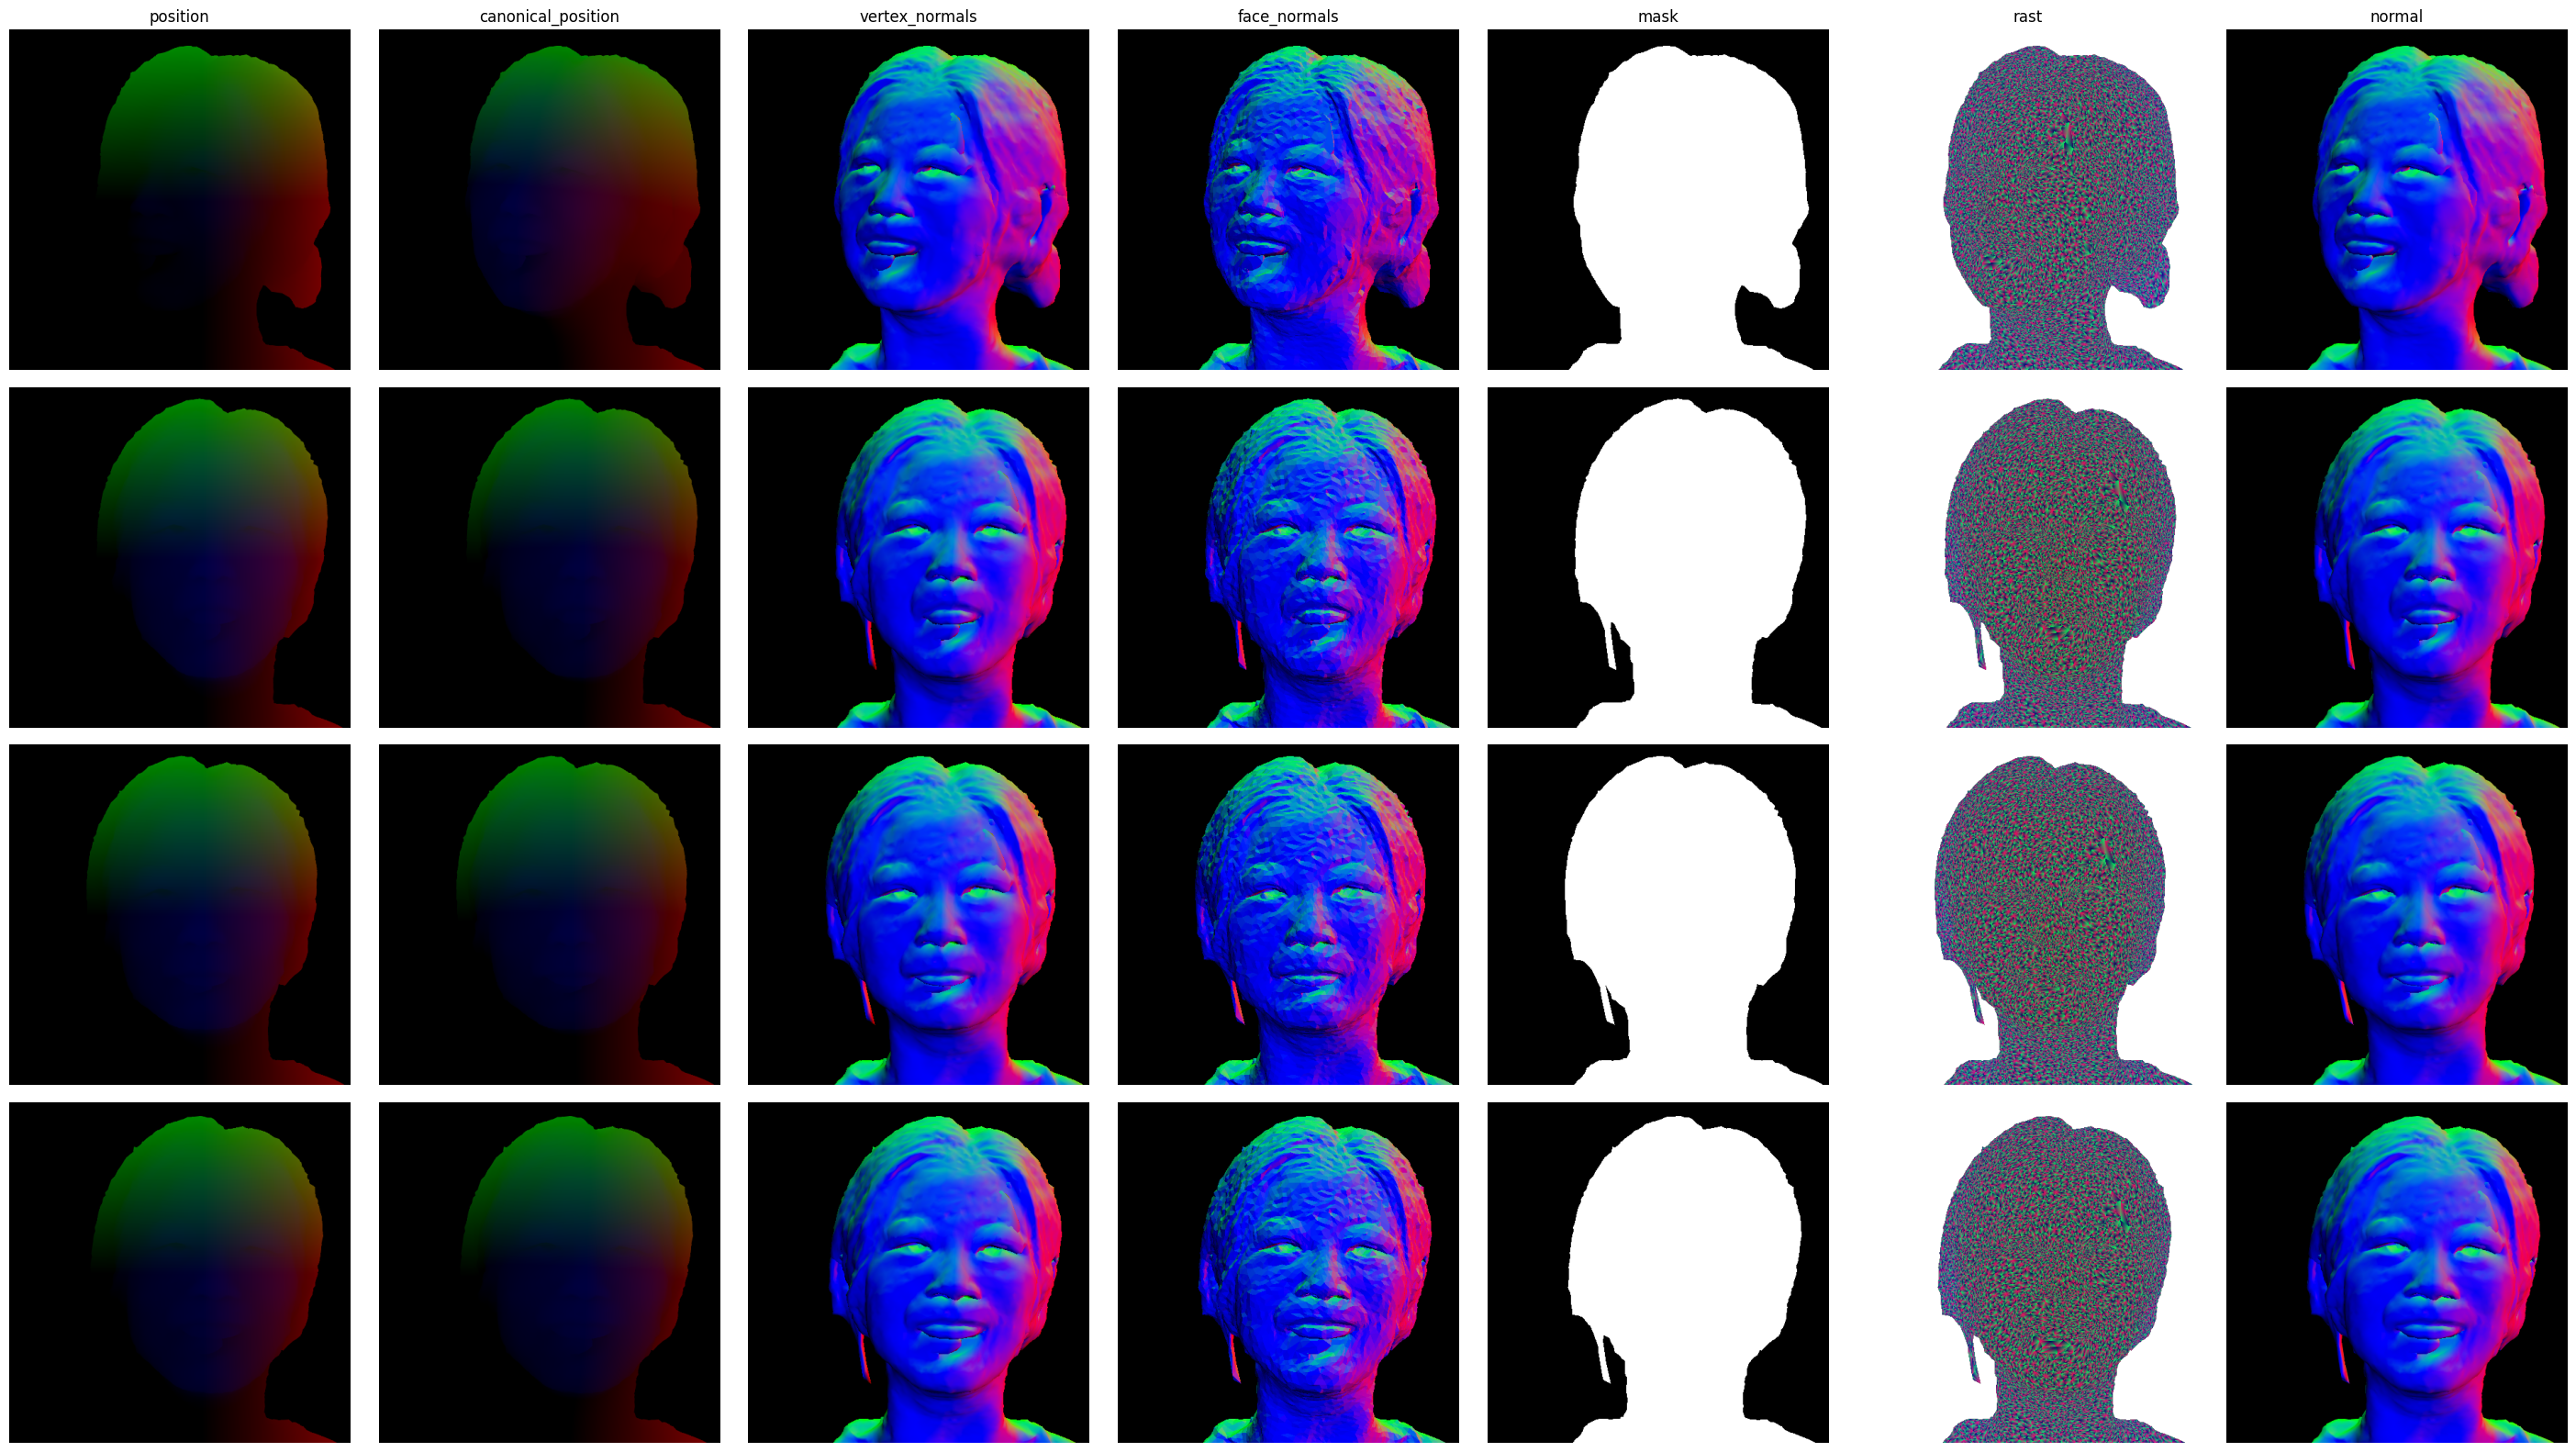

In [21]:
_gbuffers = {}
_gbuffers["position"] = gbuffers["position"]
_gbuffers["canonical_position"] = gbuffers["canonical_position"]
_gbuffers["vertex_normals"] = gbuffers["vertex_normals"]
_gbuffers["face_normals"] = gbuffers["face_normals"]
_gbuffers["mask"] = gbuffers["mask"]
_gbuffers["rast"] = gbuffers["rast"]
_gbuffers["normal"] = gbuffers["normal"]
visualize_image_buffers(_gbuffers)